In [14]:
import pandas as pd
import numpy as np

# Load the CSV file
path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed.csv"
df = pd.read_csv(path)

# Threshold-Based Attack
mean_power = df['St'].mean()
std_power = df['St'].std()
threshold_upper = mean_power + 2 * std_power
threshold_lower = mean_power - 2 * std_power

# Initially, set all labels to 0 (no attack)
df['Label'] = 0

# If power exceeds threshold, set label to 1
df.loc[(df['St'] > threshold_upper) | (df['St'] < threshold_lower), 'Label'] = 1

# Random Attacks: Randomly label 1% of the data as attacks
random_indices = np.random.choice(df.index, size=int(0.01 * len(df)), replace=False)
df.loc[random_indices, 'Label'] = 1

# Save the processed file with the synthetic attack labels
new_path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed_attack.csv"
df.to_csv(new_path, index=False)


In [15]:
import pandas as pd
import numpy as np

# Load the dataset
new_path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed_attack.csv"
df = pd.read_csv(new_path)
print(df.head())

      Pt   Qt     St  minutes_of_day  Label
0   2617  152  18391               0      0
1   5057  385  56989               0      0
2  10682  639  93000               0      0
3   4149  289  41854               0      0
4   2589  149  17852               0      0


In [20]:
import pandas as pd

# Load the CSV file
# path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed.csv"
path = r"C:/Users/olufe/projects/Appliances_Data/Dataset_new/Electricity_B1E_new2_processed_attack.csv"
df = pd.read_csv(path)

# 1. Moving Average Attack
# Calculate the moving average for the 'P' column over a window of, say, 10 minutes
df['Moving_Avg'] = df['St'].rolling(window=1).mean()

# If the actual power deviates from the moving average by more than, say, 1.5 times the standard deviation, label as attack
std_dev = df['St'].std()
df['Label_MA'] = 0  # Initialize column
df.loc[abs(df['St'] - df['Moving_Avg']) > 1.5 * std_dev, 'Label_MA'] = 1

# 2. Rapid Change Attack
# If the difference between consecutive power readings exceeds, say, 2 times the standard deviation, label as attack
df['Diff'] = df['St'].diff().fillna(0)
df['Label_RC'] = 0  # Initialize column
df.loc[abs(df['Diff']) > 2 * std_dev, 'Label_RC'] = 1

# Combine the two labels
# If either of the criteria labels a point as an attack, the combined label will also label it as an attack
df['Label'] = df[['Label_MA', 'Label_RC']].max(axis=1)

# Drop auxiliary columns used for calculations
df.drop(['Moving_Avg', 'Label_MA', 'Label_RC', 'Diff'], axis=1, inplace=True)

# Save the processed file with pattern-based synthetic attacks
new_path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed_pattern_attack.csv"
df.to_csv(new_path, index=False)


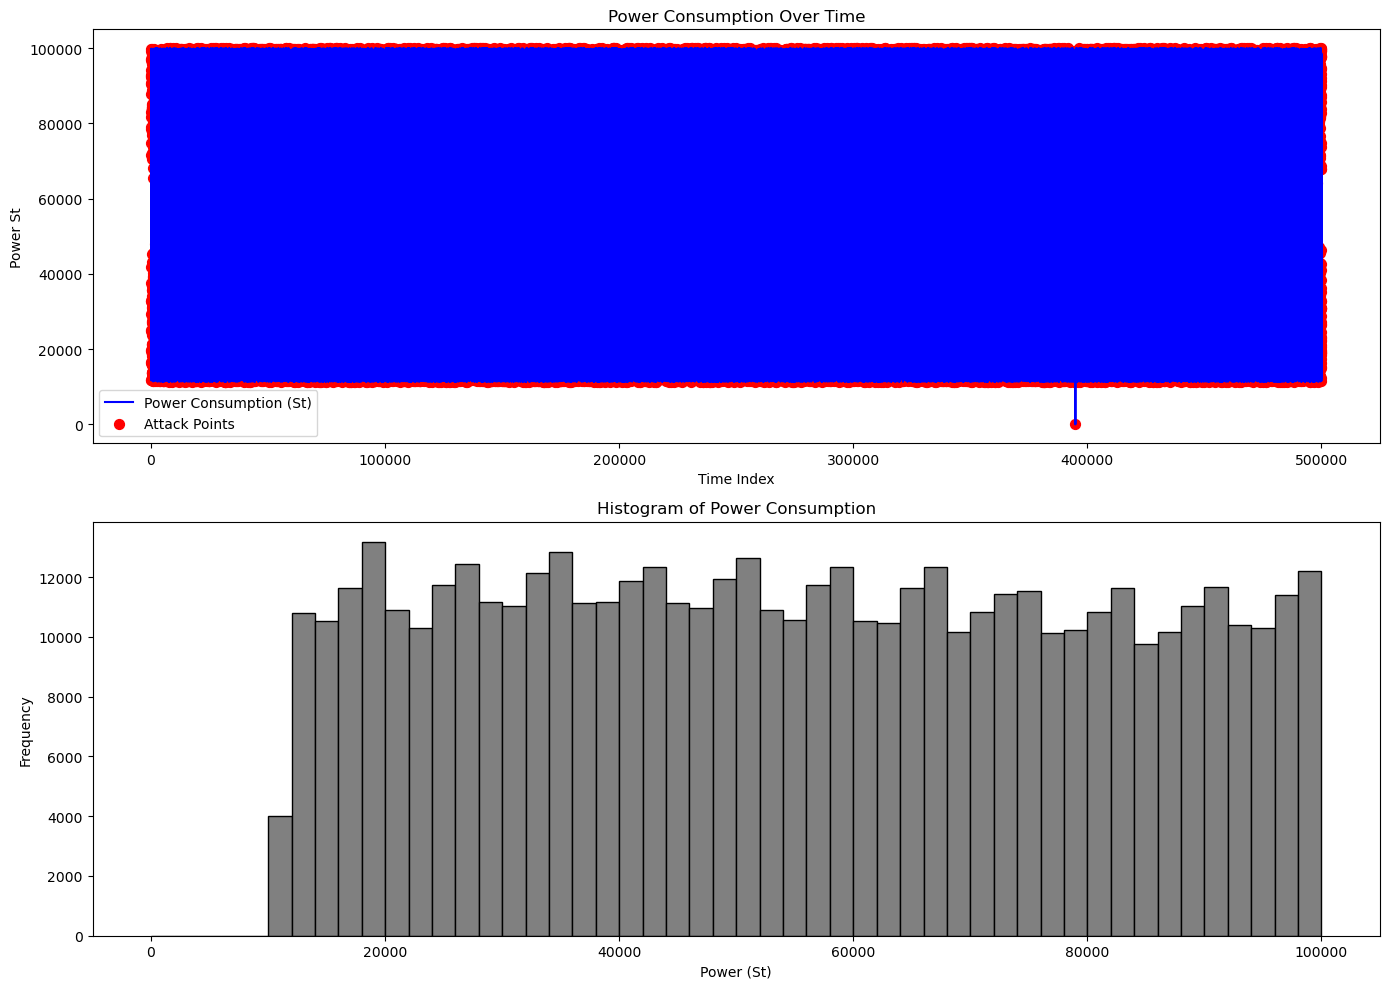

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
path = r"C:\Users\olufe\projects\Appliances_Data\Dataset_new\Electricity_B1E_new2_processed_pattern_attack.csv"
df = pd.read_csv(path)

# Visualization of the data
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

# Plotting power consumption 'P'
ax[0].plot(df['St'], color='blue', label='Power Consumption (St)')
ax[0].set_title('Power Consumption Over Time')
ax[0].set_ylabel('Power St')
ax[0].set_xlabel('Time Index')
ax[0].legend()

# Highlighting attacks in the power consumption plot
attack_indices = df[df['Label'] == 1].index
ax[0].scatter(attack_indices, df['St'].iloc[attack_indices], color='red', s=50, label='Attack Points')
ax[0].legend()

# Histogram of power consumption 'P'
ax[1].hist(df['St'], bins=50, color='gray', edgecolor='black')
ax[1].set_title('Histogram of Power Consumption')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Power (St)')

plt.tight_layout()
plt.show()
